In [47]:
import os
import sys

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.forecasting import (
    train_test_split_time_series,
    train_linear_forecast,
    predict_linear,
    evaluate_forecast
)

In [48]:
from pathlib import Path
import pandas as pd

PROCESSED_DATA_DIR = Path.cwd() / "data" / "processed"
csv_path = PROCESSED_DATA_DIR / "climate_trend_clean.csv"
if not csv_path.exists():
    csv_path = Path.cwd().parent / "data" / "processed" / "climate_trend_clean.csv"

df = pd.read_csv(csv_path)

df.head()

,Year,Temperature_Anomaly
0,1880,-0.18
1,1881,-0.09
2,1882,-0.11
3,1883,-0.18
4,1884,-0.29


In [49]:
train_df, test_df = train_test_split_time_series(
    df,
    test_size=10
)

print(train_df.shape)
print(test_df.shape)

(136, 2)
(10, 2)


In [50]:
linear_model = train_linear_forecast(train_df)

In [51]:
predictions = predict_linear(
    linear_model,
    test_df
)

predictions

array([0.49525163, 0.50228408, 0.50931652, 0.51634896, 0.5233814 ,
       0.53041384, 0.53744628, 0.54447872, 0.55151116, 0.5585436 ])

In [52]:
metrics = evaluate_forecast(
    test_df["Temperature_Anomaly"],
    predictions
)

metrics

{'MAE': 0.4881023806116115,
 'RMSE': np.float64(0.50541340833277),
 'R2': -11.445442792815953}

In [53]:
metrics_df = pd.DataFrame(
    metrics.items(),
    columns=["Metric", "Value"]
)

TABLES_DIR = Path.cwd() / "tables"
if not TABLES_DIR.exists():
    TABLES_DIR = Path.cwd().parent / "tables"

TABLES_DIR.mkdir(parents=True, exist_ok=True)

metrics_df.to_csv(
    TABLES_DIR / "forecast_metrics.csv",
    index=False
)

In [54]:
metrics_df = pd.DataFrame(
    metrics.items(),
    columns=["Metric", "Value"]
)

metrics_df.to_csv(
    TABLES_DIR / "forecast_metrics.csv",
    index=False
)

In [55]:
comparison = test_df.copy()

comparison["Predicted"] = predictions

comparison

,Year,Temperature_Anomaly,Predicted
136,2016,1.01,0.495252
137,2017,0.92,0.502284
138,2018,0.85,0.509317
139,2019,0.98,0.516349
140,2020,1.01,0.523381
141,2021,0.85,0.530414
142,2022,0.89,0.537446
143,2023,1.17,0.544479
144,2024,1.28,0.551511
145,2025,1.19,0.558544


In [56]:
comparison.to_csv(
    TABLES_DIR / "future_predictions.csv",
    index=False
)

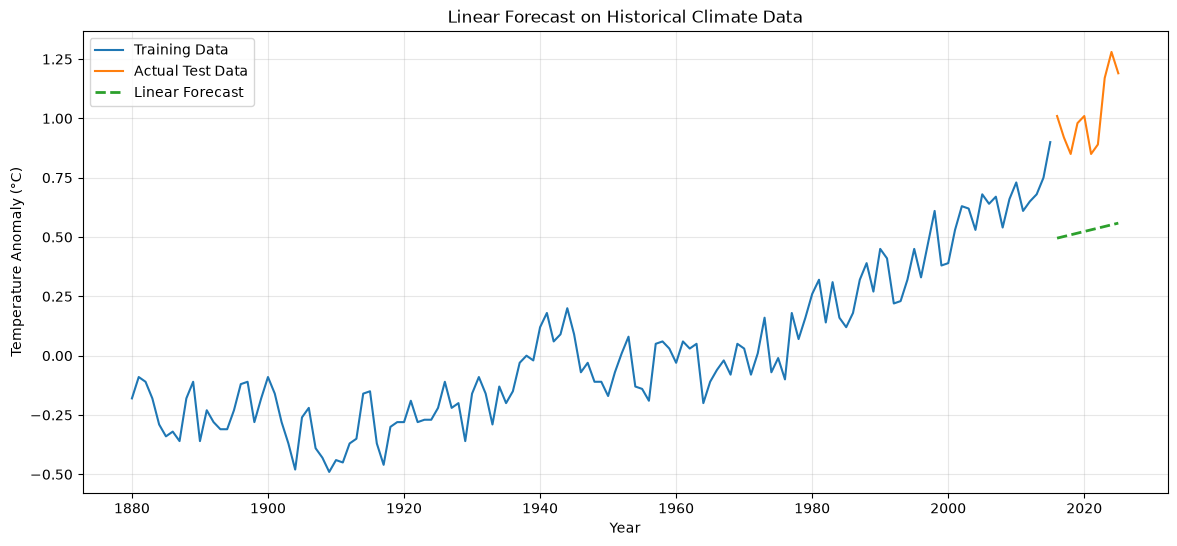

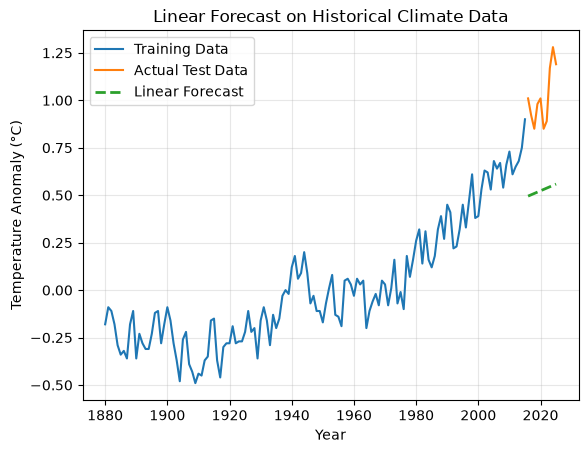

In [57]:
import matplotlib.pyplot as plt

GRAPHS_DIR = Path.cwd() / "graphs"
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(14, 6))

plt.plot(
    train_df["Year"],
    train_df["Temperature_Anomaly"],
    label="Training Data"
)

plt.plot(
    test_df["Year"],
    test_df["Temperature_Anomaly"],
    label="Actual Test Data"
)

plt.plot(
    test_df["Year"],
    predictions,
    linestyle="--",
    linewidth=2,
    label="Linear Forecast"
)

plt.title("Linear Forecast on Historical Climate Data")

plt.xlabel("Year")

plt.ylabel("Temperature Anomaly (°C)")

plt.legend()

plt.grid(alpha=0.3)

plt.savefig(
    GRAPHS_DIR / "linear_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.plot(
    train_df["Year"],
    train_df["Temperature_Anomaly"],
    label="Training Data"
)

plt.plot(
    test_df["Year"],
    test_df["Temperature_Anomaly"],
    label="Actual Test Data"
)

plt.plot(
    test_df["Year"],
    predictions,
    linestyle="--",
    linewidth=2,
    label="Linear Forecast"
)

plt.title("Linear Forecast on Historical Climate Data")

plt.xlabel("Year")

plt.ylabel("Temperature Anomaly (°C)")

plt.legend()

plt.grid(alpha=0.3)

plt.savefig(
    GRAPHS_DIR / "linear_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

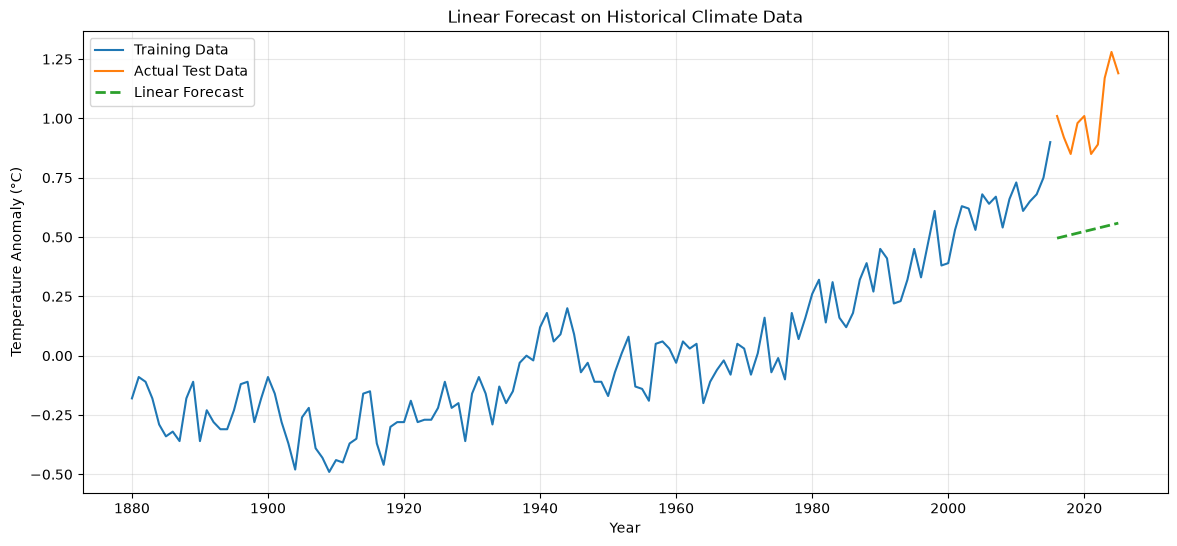

In [58]:
plt.figure(figsize=(14,6))

plt.plot(
    train_df["Year"],
    train_df["Temperature_Anomaly"],
    label="Training Data"
)

plt.plot(
    test_df["Year"],
    test_df["Temperature_Anomaly"],
    label="Actual Test Data"
)

plt.plot(
    test_df["Year"],
    predictions,
    linestyle="--",
    linewidth=2,
    label="Linear Forecast"
)

plt.title("Linear Forecast on Historical Climate Data")

plt.xlabel("Year")

plt.ylabel("Temperature Anomaly (°C)")

plt.legend()

plt.grid(alpha=0.3)

plt.savefig(
    GRAPHS_DIR / "linear_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [59]:
import statsmodels.api as sm

def train_arima(series, order=(1, 1, 1)):
    model = sm.tsa.ARIMA(series, order=order)
    return model.fit()

def predict_arima(model, start, end):
    return model.predict(start=start, end=end)

In [60]:
arima_model = train_arima(train_df["Temperature_Anomaly"])


c:\Users\shravani2006\OneDrive\Desktop\Climate-Trend-Analyzer\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [61]:
arima_predictions = predict_arima(
    arima_model,
    start=len(train_df),
    end=len(train_df) + len(test_df) - 1
)

arima_predictions

arima_predictions


136    0.815394
137    0.788251
138    0.779544
139    0.776751
140    0.775854
141    0.775567
142    0.775475
143    0.775445
144    0.775436
145    0.775433
Name: predicted_mean, dtype: float64

In [62]:
arima_predictions = predict_arima(
    arima_model,
    start=len(train_df),
    end=len(train_df) + len(test_df) - 1
)

arima_predictions

136    0.815394
137    0.788251
138    0.779544
139    0.776751
140    0.775854
141    0.775567
142    0.775475
143    0.775445
144    0.775436
145    0.775433
Name: predicted_mean, dtype: float64

In [63]:
arima_predictions = predict_arima(
    arima_model,
    start=len(train_df),
    end=len(train_df) + len(test_df) - 1
)

arima_predictions

136    0.815394
137    0.788251
138    0.779544
139    0.776751
140    0.775854
141    0.775567
142    0.775475
143    0.775445
144    0.775436
145    0.775433
Name: predicted_mean, dtype: float64

In [64]:
arima_metrics = evaluate_forecast(
    test_df["Temperature_Anomaly"],
    arima_predictions
)

arima_metrics

{'MAE': 0.23368510122142644,
 'RMSE': np.float64(0.27515616127380976),
 'R2': -2.6887168373660812}

In [65]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "ARIMA"
    ],
    "MAE": [
        metrics["MAE"],
        arima_metrics["MAE"]
    ],
    "RMSE": [
        metrics["RMSE"],
        arima_metrics["RMSE"]
    ],
    "R2": [
        metrics["R2"],
        arima_metrics["R2"]
    ]
})

comparison

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,0.488102,0.505413,-11.445443
1,ARIMA,0.233685,0.275156,-2.688717


In [66]:
comparison.to_csv(
    TABLES_DIR /
    "model_comparison.csv",
    index=False
)

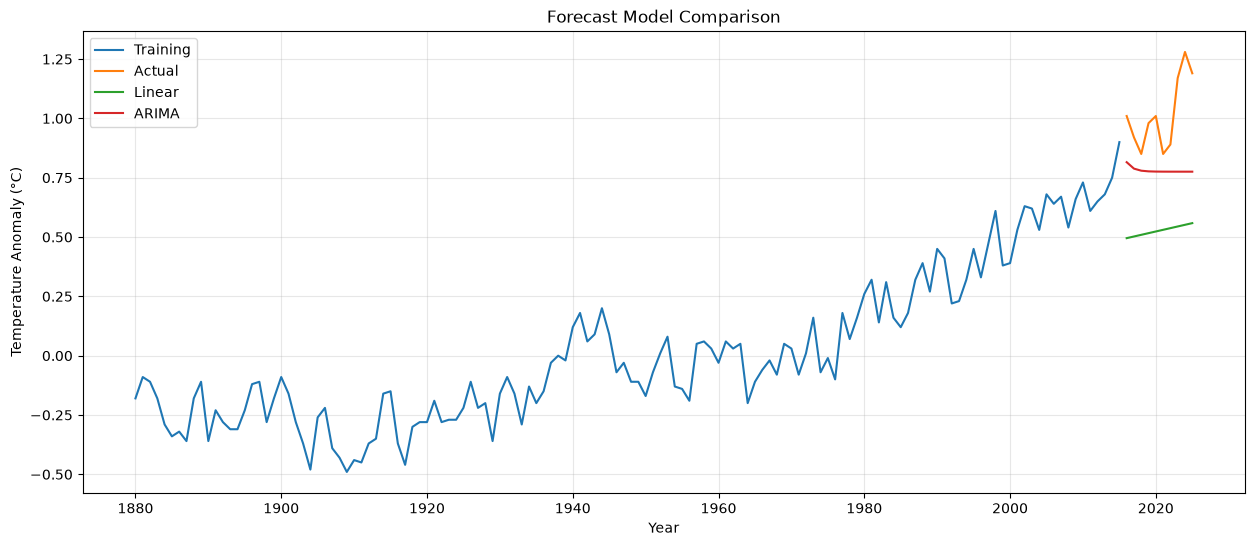

In [67]:
plt.figure(figsize=(15,6))

plt.plot(
    train_df["Year"],
    train_df["Temperature_Anomaly"],
    label="Training"
)

plt.plot(
    test_df["Year"],
    test_df["Temperature_Anomaly"],
    label="Actual"
)

plt.plot(
    test_df["Year"],
    predictions,
    label="Linear"
)

plt.plot(
    test_df["Year"],
    arima_predictions,
    label="ARIMA"
)

plt.title(
    "Forecast Model Comparison"
)

plt.xlabel("Year")

plt.ylabel(
    "Temperature Anomaly (°C)"
)

plt.legend()

plt.grid(alpha=0.3)

plt.savefig(
    GRAPHS_DIR /
    "forecast_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [68]:
final_model = train_arima(df["Temperature_Anomaly"])

In [69]:
future_predictions = final_model.get_forecast(steps=10).predicted_mean

future_predictions

future_predictions

146    1.190210
147    1.190419
148    1.190629
149    1.190839
150    1.191049
151    1.191258
152    1.191468
153    1.191678
154    1.191887
155    1.192097
Name: predicted_mean, dtype: float64

In [70]:
future_years = pd.DataFrame({
    "Year": range(
        df["Year"].max() + 1,
        df["Year"].max() + 11
    ),
    "Predicted_Temperature_Anomaly": future_predictions.values
})

future_years

,Year,Predicted_Temperature_Anomaly
0,2026,1.190210
1,2027,1.190419
2,2028,1.190629
3,2029,1.190839
4,2030,1.191049
5,2031,1.191258
6,2032,1.191468
7,2033,1.191678
8,2034,1.191887
9,2035,1.192097


In [71]:
future_years.to_csv(
    TABLES_DIR /
    "future_forecast.csv",
    index=False
)

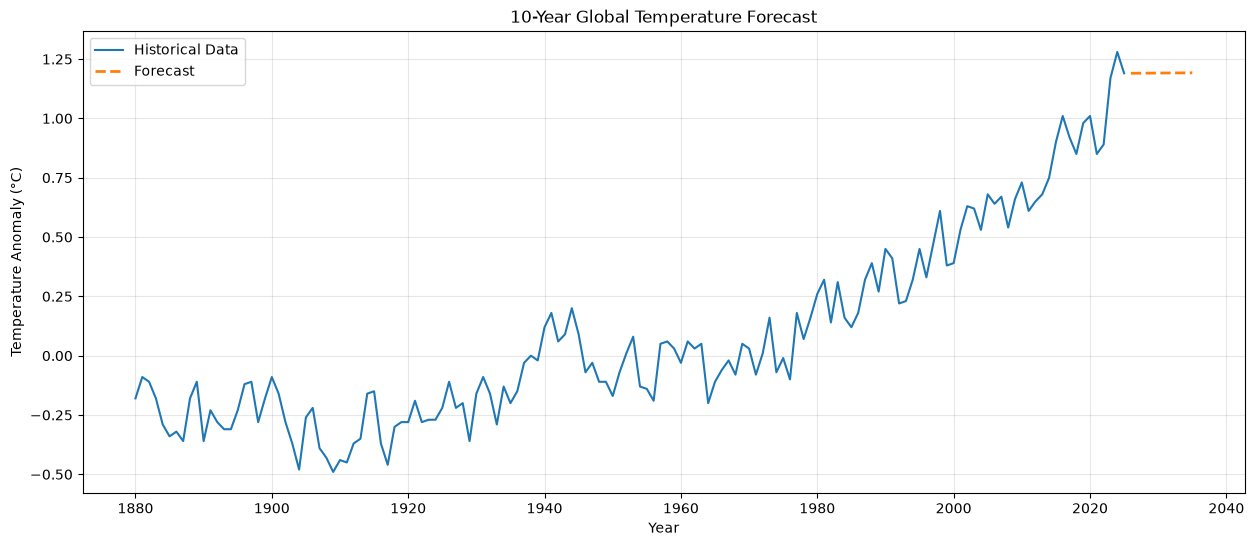

In [72]:
plt.figure(figsize=(15,6))

plt.plot(
    df["Year"],
    df["Temperature_Anomaly"],
    label="Historical Data"
)

plt.plot(
    future_years["Year"],
    future_years["Predicted_Temperature_Anomaly"],
    linestyle="--",
    linewidth=2,
    label="Forecast"
)

plt.title(
    "10-Year Global Temperature Forecast"
)

plt.xlabel("Year")

plt.ylabel("Temperature Anomaly (°C)")

plt.legend()

plt.grid(alpha=0.3)

plt.savefig(
    GRAPHS_DIR /
    "future_10_year_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [73]:
from src.validation import (
    calculate_residuals
)

In [74]:
residuals = calculate_residuals(
    test_df["Temperature_Anomaly"],
    arima_predictions
)

In [75]:
residual_summary = pd.DataFrame({

    "Statistic":[
        "Mean",
        "Std",
        "Maximum",
        "Minimum"
    ],

    "Value":[
        residuals.mean(),
        residuals.std(),
        residuals.max(),
        residuals.min()
    ]

})

residual_summary

,Statistic,Value
0,Mean,0.233685
1,Std,0.153124
2,Maximum,0.504564
3,Minimum,0.070456


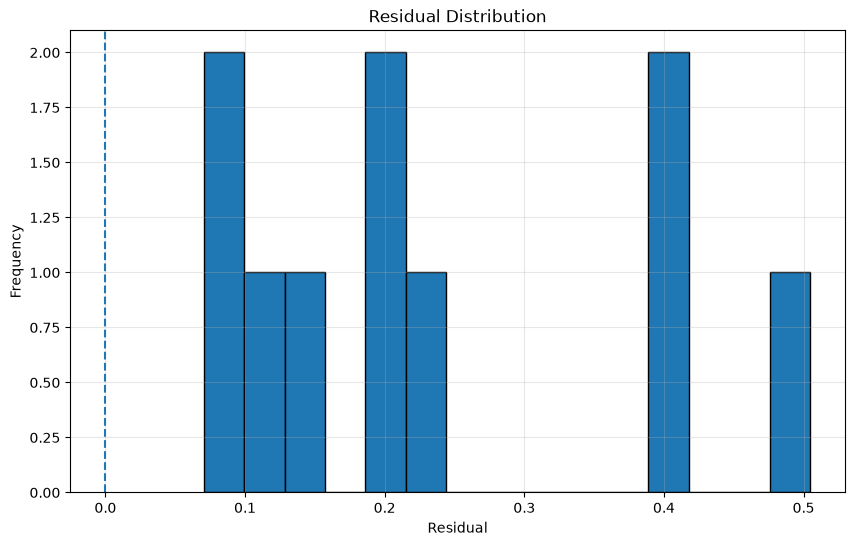

In [76]:
plt.figure(figsize=(10,6))

plt.hist(
    residuals,
    bins=15,
    edgecolor="black"
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Residual Distribution"
)

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.savefig(
    GRAPHS_DIR /
    "residual_distribution.png",
    dpi=300
)

plt.show()

In [77]:
prediction_df = test_df.copy()

prediction_df["Prediction"] = (
    arima_predictions.values
)

prediction_df["Residual"] = (
    prediction_df["Temperature_Anomaly"]
    -
    prediction_df["Prediction"]
)

prediction_df["Absolute_Error"] = (
    prediction_df["Residual"].abs()
)

prediction_df

,Year,Temperature_Anomaly,Prediction,Residual,Absolute_Error
136,2016,1.01,0.815394,0.194606,0.194606
137,2017,0.92,0.788251,0.131749,0.131749
138,2018,0.85,0.779544,0.070456,0.070456
139,2019,0.98,0.776751,0.203249,0.203249
140,2020,1.01,0.775854,0.234146,0.234146
141,2021,0.85,0.775567,0.074433,0.074433
142,2022,0.89,0.775475,0.114525,0.114525
143,2023,1.17,0.775445,0.394555,0.394555
144,2024,1.28,0.775436,0.504564,0.504564
145,2025,1.19,0.775433,0.414567,0.414567


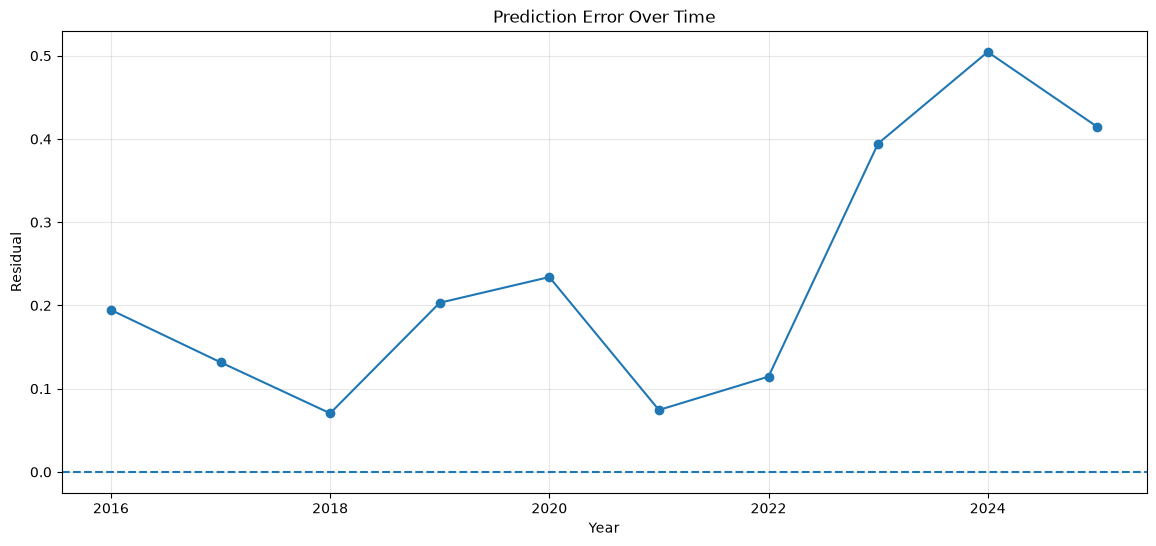

In [78]:
plt.figure(figsize=(14,6))

plt.plot(
    prediction_df["Year"],
    prediction_df["Residual"],
    marker="o"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "Prediction Error Over Time"
)

plt.xlabel("Year")

plt.ylabel("Residual")

plt.grid(alpha=0.3)

plt.savefig(
    GRAPHS_DIR /
    "prediction_error.png",
    dpi=300
)

plt.show()

In [79]:
project_root = Path.cwd().parent
os.chdir(project_root)

from src.settings import settings
print(settings)

{'project': {'name': 'Climate Trend Analyzer'}, 'forecast': {'model': 'arima', 'years': 15}, 'anomaly': {'zscore_threshold': 2, 'iqr_multiplier': 1.5}, 'plots': {'dpi': 300}}


In [80]:
print(settings["forecast"]["years"])

15


In [81]:
from src.output_validator import validate_outputs

validate_outputs()

FileNotFoundError: outputs/graphs missing.

In [ ]:
from src.settings import settings

print(settings["forecast"]["years"])

15


In [83]:
# Load the processed CSV using the existing csv_path (defined in an earlier cell)
df = pd.read_csv(csv_path)
df.head()

,Year,Temperature_Anomaly
0,1880,-0.18
1,1881,-0.09
2,1882,-0.11
3,1883,-0.18
4,1884,-0.29


In [85]:
def preprocess_data(df):
    df = df.copy()
    df = df.dropna(subset=["Year", "Temperature_Anomaly"])
    df["Year"] = df["Year"].astype(int)
    df["Temperature_Anomaly"] = df["Temperature_Anomaly"].astype(float)
    return df

clean_df = preprocess_data(df)

In [ ]:
from src.eda import perform_eda

import matplotlib.pyplot as plt

try:
    perform_eda
except NameError:
    def perform_eda(df):
        df = df.copy()

        print("Dataset shape:", df.shape)
        print("\nPreview:")
        print(df.head())

        print("\nMissing values:")
        print(df.isnull().sum())

        print("\nSummary statistics:")
        print(df.describe())

        GRAPHS_DIR.mkdir(parents=True, exist_ok=True)

        plt.figure(figsize=(12, 4))
        plt.plot(df["Year"], df["Temperature_Anomaly"], marker="o")
        plt.title("Temperature Anomaly Over Time")
        plt.xlabel("Year")
        plt.ylabel("Temperature Anomaly (°C)")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(
            GRAPHS_DIR / "eda_temperature_anomaly.png",
            dpi=300,
            bbox_inches="tight"
        )
        plt.show()

perform_eda(clean_df)

IndentationError: expected an indented block after 'try' statement on line 5 (1895492587.py, line 6)